# Workshop: Can We Trust This Connectivity Analysis?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

A collaborator (or an LLM) gave us this notebook to answer the following scientific question:

**What is the probability that one excitatory neuron connects to another as a function of soma–soma distance?**

The notebook runs without errors and produces a reasonable-looking figure.

**Can we trust the result?**

Rather than assuming the code is correct—or incorrect—we'll build evidence by reading the code, visualizing intermediate results, testing simple cases, and comparing against known expectations.

</div>

In [1]:
# HOW TO USE (for now): Run the code with all bugs on, then perform each test below, 
# and toggle off the corresponding bug to automatically fix the code and move 
# to the next bug. In practice, students will implement these solutions. 

BUG_1 = False #Using soma depth only, not euclidean distance 
BUG_2 = False #Wrong denominator in our probability 


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Analysis code we received

Run the notebook below to generate the final result.

At first glance, does the figure look plausible?

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

DATA_DIR = Path("/root/capsule/data/v1dd_1196")
MAT = 1196
BIN_WIDTH_UM = 25.0
MAX_DISTANCE_UM = 900.0
MIN_PAIRS_PER_BIN = 200

### Functions

In [3]:
def read_feather(path, columns=None):
    """Read a Feather/Arrow IPC file."""
    with open(path, "rb") as fh:
        table = ipc.open_file(fh).read_all()
    if columns is not None:
        table = table.select(columns)
    return table.to_pandas()


def get_soma_positions(cell_df, position_columns):
    """Return soma coordinates for each root ID."""

    positions = (
        cell_df
        .set_index("pt_root_id")[position_columns]
        .to_numpy(dtype=float)
    ) / 1000.0
    
    return positions, position_columns


def distance_from_one_soma(pre_position, post_positions):
    """Calculate the distance from one soma to every candidate postsynaptic soma."""

    if BUG_1:
        #BUG this is using only the y coordinate (cortical depth) difference, rather than euclidean distance 
        return np.abs(post_positions[:, 1] - pre_position[1]) 
    else:
        return np.linalg.norm(post_positions - pre_position, axis=1)


def unique_connected_pairs(synapses, pre_ids, post_ids):
    """Find unique connected non-self pre/post pairs in the eligible pools."""

    eligible = (
        synapses["pre_pt_root_id"].isin(pre_ids)
        & synapses["post_pt_root_id"].isin(post_ids)
        & (
            synapses["pre_pt_root_id"]
            != synapses["post_pt_root_id"]
        )
        )

    return (
        synapses.loc[
            eligible,
            ["pre_pt_root_id", "post_pt_root_id"],
        ]
        .drop_duplicates()
    )


def count_pairs_by_distance(
    pre_ids,
    post_ids,
    pre_positions,
    post_positions,
    connected_pairs,
    bin_width_um=25.0,
    max_distance_um=900.0,
):
    """Count eligible and connected ordered pairs in distance bins."""
    edges = np.arange(0, max_distance_um + bin_width_um, bin_width_um)
    n_bins = len(edges) - 1
    total_counts = np.zeros(n_bins, dtype=int)
    connected_counts = np.zeros(n_bins, dtype=int)

    post_id_to_row = {root_id: i for i, root_id in enumerate(post_ids)}
    connected_by_pre = {
        pre_id: np.array(
            [post_id_to_row[p] for p in group["post_pt_root_id"] if p in post_id_to_row],
            dtype=int,
        )
        for pre_id, group in connected_pairs.groupby("pre_pt_root_id")
    }

    for i, pre_id in enumerate(pre_ids):
        distances = distance_from_one_soma(pre_positions[i], post_positions)

        self_row = post_id_to_row.get(pre_id)
        if self_row is not None:
            distances[self_row] = np.nan

        valid = np.isfinite(distances) & (distances < max_distance_um)
        bins = np.floor(distances[valid] / bin_width_um).astype(int)
        total_counts += np.bincount(bins, minlength=n_bins)[:n_bins]

        connected_rows = connected_by_pre.get(pre_id, np.array([], dtype=int))
        connected_distances = distances[connected_rows]
        valid_connected = (
            np.isfinite(connected_distances)
            & (connected_distances < max_distance_um)
        )
        connected_bins = np.floor(
            connected_distances[valid_connected] / bin_width_um
        ).astype(int)
        connected_counts += np.bincount(
            connected_bins, minlength=n_bins
        )[:n_bins]

    return edges, total_counts, connected_counts

def connection_probability(connected_counts, total_counts):
    """Calculate connection probability and Wilson confidence intervals."""

    connected_counts = np.asarray(connected_counts)
    total_counts = np.asarray(total_counts)

    if BUG_2:
        # BUG: Uses the total number of eligible pairs across all distance bins
        # instead of only the eligible pairs in each bin.
        denominator = total_counts.sum()
        probability = connected_counts / denominator
        ci_denominator = np.full_like(connected_counts, denominator)

    else:
        # Correct: each distance bin has its own denominator.
        probability = np.divide(
            connected_counts,
            total_counts,
            out=np.full(connected_counts.shape, np.nan, dtype=float),
            where=total_counts > 0,
        )

    return probability 

### Load the V1DD data

In [4]:
cell = read_feather(DATA_DIR / f"soma_and_cell_type_{MAT}.feather")
proofread_axon_ids = np.load(DATA_DIR / f"proofread_axon_list_{MAT}.npy")
proofread_dendrite_ids = np.load(DATA_DIR / f"proofread_dendrite_list_{MAT}.npy")

synapses = read_feather(
    DATA_DIR / f"syn_df_all_to_proofread_to_all_{MAT}.feather",
    columns=["pre_pt_root_id", "post_pt_root_id"],
)

cell.shape, synapses.shape

((207455, 11), (8204497, 2))

### Extract excitatory cells

In [5]:
soma_coord_columns = ["pt_position_trform_x", "pt_position_trform_y", "pt_position_trform_z"]

excitatory_cells = cell.loc[
    (cell["cell_type_coarse"] == "E")
    & (cell["pt_root_id"] != 0)
].copy()

excitatory_cells = (
    excitatory_cells
    .dropna(subset=soma_coord_columns)
    .drop_duplicates("pt_root_id")
)

pre_cells = excitatory_cells.loc[
    excitatory_cells["pt_root_id"].isin(proofread_axon_ids)
].copy()

post_cells = excitatory_cells.loc[
    excitatory_cells["pt_root_id"].isin(proofread_dendrite_ids)
].copy()

pre_ids = pre_cells["pt_root_id"].to_numpy()
post_ids = post_cells["pt_root_id"].to_numpy()

all_positions, position_columns = get_soma_positions(excitatory_cells, soma_coord_columns)
root_to_row = {
    root_id: i
    for i, root_id in enumerate(excitatory_cells["pt_root_id"].to_numpy())
}
pre_positions = all_positions[[root_to_row[root_id] for root_id in pre_ids]]
post_positions = all_positions[[root_to_row[root_id] for root_id in post_ids]]

connected_pairs = unique_connected_pairs(synapses, pre_ids, post_ids)

### Run the analysis and make the figure

In [6]:
edges, total_counts, connected_counts = count_pairs_by_distance(
    pre_ids,
    post_ids,
    pre_positions,
    post_positions,
    connected_pairs,
    bin_width_um=BIN_WIDTH_UM,
    max_distance_um=MAX_DISTANCE_UM,
)

probability = connection_probability(
    connected_counts,
    total_counts,
)

centers = (edges[:-1] + edges[1:]) / 2
results = pd.DataFrame({
    "distance_bin_center_um": centers,
    "n_pairs": total_counts,
    "n_connected": connected_counts,
    "connection_probability": probability
})


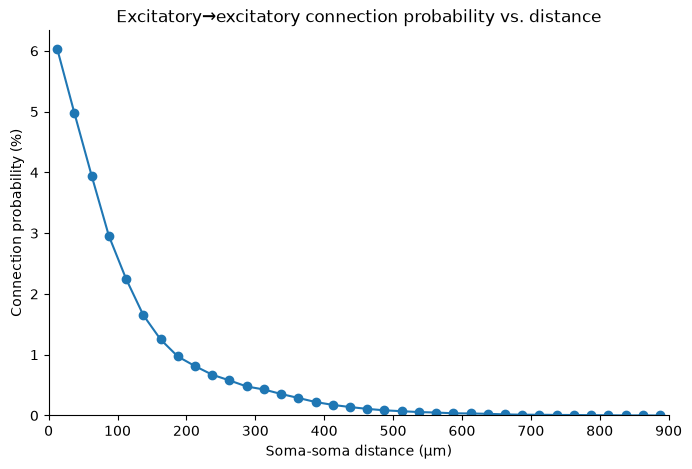

In [7]:
reliable = total_counts >= MIN_PAIRS_PER_BIN
show = reliable & np.isfinite(probability)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    centers[show],
    probability[show] * 100,
    marker="o",
)
ax.set(
    xlabel="Soma-soma distance (µm)",
    ylabel="Connection probability (%)",
    title="Excitatory→excitatory connection probability vs. distance",
    xlim=(0, MAX_DISTANCE_UM),
    ylim=(0, None),
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Can we trust this result?

The figure looks reasonable—but appearances aren't enough.

Let's start building evidence by checking one assumption at a time. We'll begin with one of the key quantities in the analysis: the distance between neuron somata.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

Visualizing the real data helped us identify an issue with the soma coordinate values being used, but **it doesn't prove the distance calculation is correct.**

### **Check 1: How is soma distance calculated?**

The analysis should calculate the **Euclidean distance** between soma coordinates. The MICrONS volume spans approximately 1.4 × 0.87 × 0.84 mm. The possible soma-soma distance range is therefore 0 mm to ~1.85 mm. 



</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **visualize** the soma distances

</div>

(BUG_1)

Given:

In [8]:
#Compute all soma-soma distances
#TODO 

#Plot distances 
#TODO 

Solution:

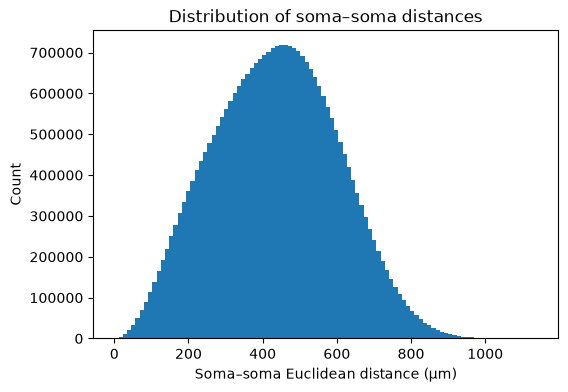

In [9]:
#Compute all soma-soma distances
all_distances = []
for i, pre_id in enumerate(pre_ids):
    distances = distance_from_one_soma(pre_positions[i], post_positions)
    all_distances.append(distances)
all_distances = np.concatenate(all_distances)

#Plot distances 
plt.figure(figsize=(6, 4))
plt.hist(all_distances, bins=100)
plt.xlabel("Soma–soma Euclidean distance (μm)")
plt.ylabel("Count")
plt.title("Distribution of soma–soma distances")
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### This range is smaller than we'd expect

Visualizing the distance distribution can reveal suspicious results, but it doesn't verify that the distance calculation is correct.

To test the implementation directly, we'll run the function on a small **test dataset** of soma coordinates with known Euclidean distances. If it fails these simple, hand-calculated examples, we shouldn't trust its results on the full dataset.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Create **test data** to assess the soma distance calculation

</div>

(BUG_1)

Given:

In [10]:
#Test two soma coordinates at different positions, but with the same cortical depth
pre_test =  np.array([  TODO  ])
post_test = np.array([[   TODO   ]])

# Determine what the distance *should* be 
expected_distance = #TODO 

# Run the existing function that calculates the distance between them 
calculated_distance = #TODO 

# Does the expected distance equal the calculated distance?
print("Calculated distance:", calculated_distance)
print("Expected distance:  ", expected_distance)


SyntaxError: invalid syntax (3541223675.py, line 6)

Solution

In [ ]:
#Test two soma coordinates at different positions, but with the same cortical depth

pre_test = np.array([0.0, 10.0, 0.0])
post_test = np.array([[0.0, 10.0, 5.0]])

# Determine what the distance *should* be 
expected_distance = 5.0

# Run the existing function that calculates the distance between them 
calculated_distance = distance_from_one_soma(pre_test, post_test)[0]

# Does the expected distance equal the calculated distance?
print("Calculated distance:", calculated_distance)
print("Expected distance:  ", expected_distance)


Calculated distance: 5.0
Expected distance:   5.0


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### The test failed

Our test data shows that the distance function does **not** return the expected values.

Before fixing the code, let's turn this check into an **assertion**. An assertion is a simple test that verifies a condition is true while the code runs. If the condition isn't met, the program immediately raises an error.

We'll first watch the assertion fail, then inspect the implementation, fix the bug, and rerun the assertion to confirm the fix.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Turn this check into an **assert** statement
Hint: how can we deal with floating point differences?

</div>


Given:

Solution:

In [ ]:
# Add an assert statement to catch this test
assert np.isclose(calculated_distance, expected_distance), (
    f"Expected distance {expected_distance}, "
    f"but got {calculated_distance}."
)

#TODO prompt students to write more tests to identify the bug?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **fix the bug**

Use the failing assertion to guide your debugging.

- Write more tests to understand what the error in the calculation is. 
- Find and fix the bug in the distance function.
- Rerun the code. Once the assertion test passes, continue to the next section.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Reflection

The assertion now passes—but one passing test doesn't prove the function is correct.

**What other unit tests could you write to increase your confidence in this function?**

Take a minute to brainstorm a few additional cases before moving on. 

*If you finish this part of the exercise early, write several additional tests and organize them into a unit test function that can be run with `pytest`.*

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### **Check 3: Is connection probability calculated correctly?**

Before reading the code, clarify the quantity we want to calculate within each soma-distance bin:

$$
P(\text{connection} \mid \text{distance bin})
= 
\frac{???}{???}
$$

* What should be counted in the numerator?
* What should be counted in the denominator?
* Which neuron pairs should be considered eligible?

Then brainstorm ways to test whether the code actually computes this quantity.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Create another **test case**, then **visually inspect** the probability function

</div>

(BUG_2)

Given:

In [ ]:
# create test data for two depth bins where the number of 
# connected and eligible pairs is different but the proportions
# are the same across the bins. 
#TODO 

# Determine what the probabilities *should* be 
#TODO

# Run the existing function to calculate the probability 
# of connectivity across the depth bins
#TODO 

# Write an assertion that checks if the expectation is met 
#TODO 

Solution:

In [ ]:
# create test data for two depth bins where the number of 
# connected and eligible pairs is different but the proportions
# are the same across the bins. 

connected_counts = np.array([1, 10])
total_counts = np.array([10, 100])

# Determine what the probabilities *should* be 
expected_probability = [0.1, 0.1]

# Run the existing function to calculate the probability 
# of connectivity across the depth bins
probability = connection_probability(
    connected_counts, 
    total_counts,
)

# Write an assertion that checks if the expectation is met 
assert np.allclose(probability, expected_probability), (
    f"Expected probabilities {expected_probability}, but got {probability}."
)

AssertionError: Expected probabilities [0.1, 0.1], but got [0.00909091 0.09090909].

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### The test failed

The result from our test data does not match the expected connection probability, so the analysis is not calculating the quantity correctly.



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Go back to the probability function and inspect how it computes:

* the number of connected pairs in each distance bin
* the total number of eligible pairs in each distance bin

Can you **identify the problem from the code?** If not, **design another small test** that isolates the numerator or denominator and helps reveal what is being counted incorrectly.



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **fix the bug**

Use the failing assertion to guide your debugging.

- Fix the bug in the probability function.
- Rerun the assertion until it passes.
- Once the test passes, continue.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Another way to build confidence: compare to peer-reviewed studies

Another way to evaluate an analysis is to compare your results to independent findings from the scientific literature.

If previous studies using the same or similar datasets report comparable trends, that increases confidence that your implementation is reasonable. If your results differ substantially, that's a signal to investigate further—it may reveal a bug, a difference in methodology, or a genuinely new finding.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### **If you've finished this exercise early...**

* Find one or more published studies related to excitatory-to-excitatory connection probability as a function of soma distance.
* Compare their findings to your result.
* Does the comparison increase or decrease your confidence in the analysis? Why?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Discussion

### What other assumptions would you want to test, and how could you test them?

Think beyond the bugs we found today. What assumptions does this analysis make about the data, filtering, units, neuron identities, eligible pairs, binning, or interpretation of the result?

For each assumption, identify a piece of evidence that would increase—or decrease—your confidence in the analysis.

</div>


The End